# HW12 - Time Series Forecasting (S12)

Практическая работа 12 - Атаманчук А.В. КВБО-01-22


1) Импорты, seed и среда


In [1]:
import copy
import json
import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
WINDOW_SIZE = 24
HORIZON = 1
MAX_EPOCHS = 30
BATCH_SIZE = 64
LR = 1e-3

ROOT_DIR = Path.cwd()
ARTIFACTS_DIR = ROOT_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def locate_dataset(root_dir: Path) -> Path:
    dataset_path = root_dir / "S12-hw-dataset.csv"
    if dataset_path.exists():
        return dataset_path
    raise FileNotFoundError("Local file S12-hw-dataset.csv not found in HW12 folder.")


set_seed(SEED)
DEVICE = get_device()
print("seed:", SEED)
print("device:", DEVICE)


seed: 42
device: cuda


2) Данные и первичный анализ


dataset path: d:\VUZ\II_DOP_KURS\MIREA_III\homeworks\HW12\S12-hw-dataset.csv
rows: 4320
date range: 2025-01-01 00:00:00 -> 2025-06-29 23:00:00
missing values:
 date      0
target    0
dtype: int64


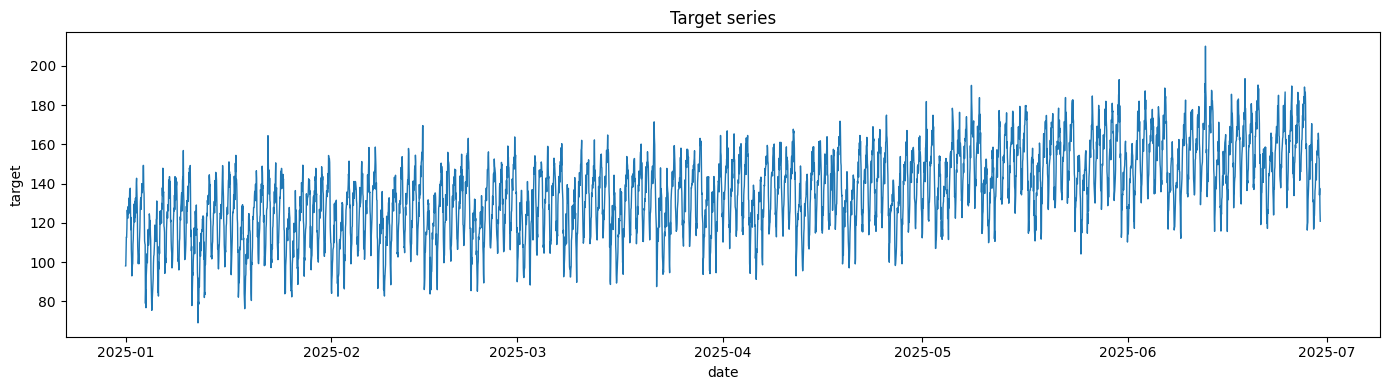

In [2]:
DATASET_PATH = locate_dataset(ROOT_DIR)
df = pd.read_csv(DATASET_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("dataset path:", DATASET_PATH)
print("rows:", len(df))
print("date range:", df["date"].min(), "->", df["date"].max())
print("missing values:\n", df.isna().sum())

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["date"], df["target"], color="tab:blue", linewidth=1)
ax.set_title("Target series")
ax.set_xlabel("date")
ax.set_ylabel("target")
fig.tight_layout()
plt.show()
plt.close(fig)


3) Корректный temporal split


train: <= 2025-05-06 23:00:00, val: (2025-05-06 23:00:00, 2025-06-02 23:00:00], test: > 2025-06-02 23:00:00
split sizes: 3024 648 648


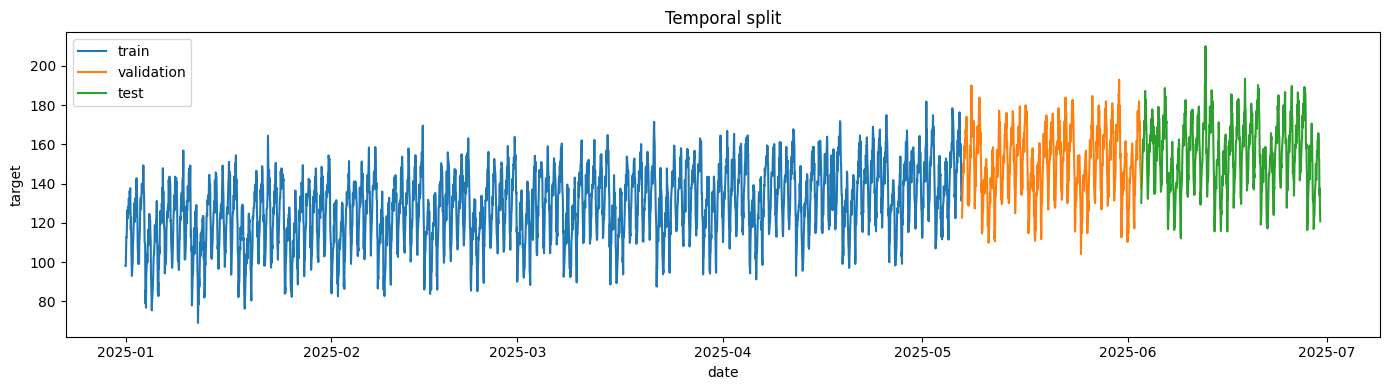

In [3]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

train_end_date = train_df["date"].iloc[-1]
val_end_date = val_df["date"].iloc[-1]

split_summary = (
    f"train: <= {train_end_date}, "
    f"val: ({train_end_date}, {val_end_date}], "
    f"test: > {val_end_date}"
)
print(split_summary)
print("split sizes:", len(train_df), len(val_df), len(test_df))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df["date"], train_df["target"], label="train", color="tab:blue")
ax.plot(val_df["date"], val_df["target"], label="validation", color="tab:orange")
ax.plot(test_df["date"], test_df["target"], label="test", color="tab:green")
ax.set_title("Temporal split")
ax.set_xlabel("date")
ax.set_ylabel("target")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "series_split.png", dpi=150)
plt.show()
plt.close(fig)


## Почему random split для временного ряда некорректен

`random split` для временного ряда некорректен, потому что перемешивает прошлое и будущее: модель получает доступ к паттернам из будущих периодов, которые недоступны в реальном прогнозе. Это приводит к утечке данных и завышению метрик. Поэтому для временных рядов используется только хронологический `temporal split` (`train -> validation -> test`).


4) Признаки для baseline-моделей (B1/B2/B3)


In [4]:
def metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.clip(np.abs(y_true), 1e-8, None)
    mape = float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)
    return {"mae": float(mae), "rmse": float(rmse), "mape": mape}


feat_df = df.copy()
feat_df["lag_1"] = feat_df["target"].shift(1)
feat_df["lag_7"] = feat_df["target"].shift(7)
feat_df["lag_14"] = feat_df["target"].shift(14)
feat_df["rolling_mean_7"] = feat_df["target"].shift(1).rolling(7).mean()
feat_df["rolling_std_7"] = feat_df["target"].shift(1).rolling(7).std()
feat_df["dow"] = feat_df["date"].dt.dayofweek
feat_df["hour"] = feat_df["date"].dt.hour

feat_df = feat_df.dropna().reset_index(drop=True)

train_feat = feat_df[feat_df["date"] <= train_end_date].copy()
val_feat = feat_df[(feat_df["date"] > train_end_date) & (feat_df["date"] <= val_end_date)].copy()
test_feat = feat_df[feat_df["date"] > val_end_date].copy()

feature_cols = ["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_std_7", "dow", "hour"]

y_val = val_feat["target"].to_numpy()
y_test = test_feat["target"].to_numpy()

# B1 naive-last
b1_val_pred = val_feat["lag_1"].to_numpy()
b1_val = metrics(y_val, b1_val_pred)

# B2 moving-average
b2_val_pred = val_feat["rolling_mean_7"].to_numpy()
b2_val = metrics(y_val, b2_val_pred)

# B3 ridge-lag-features
tab_scaler = StandardScaler()
X_train = tab_scaler.fit_transform(train_feat[feature_cols].to_numpy())
X_val = tab_scaler.transform(val_feat[feature_cols].to_numpy())
X_test = tab_scaler.transform(test_feat[feature_cols].to_numpy())
y_train = train_feat["target"].to_numpy()

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
b3_val_pred = ridge.predict(X_val)
b3_val = metrics(y_val, b3_val_pred)

print("B1 val:", b1_val)
print("B2 val:", b2_val)
print("B3 val:", b3_val)


B1 val: {'mae': 6.444814814814815, 'rmse': 8.20102295260389, 'mape': 4.39792166354992}
B2 val: {'mae': 12.702012786596118, 'rmse': 15.217644526713752, 'mape': 8.81686403093607}
B3 val: {'mae': 6.360190695449106, 'rmse': 7.886870745106799, 'mape': 4.282034673106465}


## 5) Оконное представление и GRU (R1)


In [5]:
def make_windows(series: np.ndarray, window_size: int):
    X, y, idx = [], [], []
    for i in range(window_size, len(series)):
        X.append(series[i - window_size : i])
        y.append(series[i])
        idx.append(i)
    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(idx, dtype=np.int64),
    )


target_values = df["target"].to_numpy(dtype=np.float32)
target_scaler = StandardScaler()
target_scaler.fit(target_values[:train_end].reshape(-1, 1))
target_scaled = target_scaler.transform(target_values.reshape(-1, 1)).reshape(-1)

X_all, y_all, idx_all = make_windows(target_scaled, WINDOW_SIZE)

train_mask = idx_all < train_end
val_mask = (idx_all >= train_end) & (idx_all < val_end)
test_mask = idx_all >= val_end

X_train_seq, y_train_seq = X_all[train_mask], y_all[train_mask]
X_val_seq, y_val_seq = X_all[val_mask], y_all[val_mask]
X_test_seq, y_test_seq = X_all[test_mask], y_all[test_mask]
idx_val_seq, idx_test_seq = idx_all[val_mask], idx_all[test_mask]

train_ds = TensorDataset(torch.from_numpy(X_train_seq), torch.from_numpy(y_train_seq))
val_ds = TensorDataset(torch.from_numpy(X_val_seq), torch.from_numpy(y_val_seq))
test_ds = TensorDataset(torch.from_numpy(X_test_seq), torch.from_numpy(y_test_seq))

pin = DEVICE.type == "cuda"
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin)


class GRURegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.unsqueeze(-1)
        out, _ = self.gru(x)
        return self.head(out[:, -1, :]).squeeze(-1)


@torch.no_grad()
def predict_scaled(model: nn.Module, loader: DataLoader):
    model.eval()
    preds, trues = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        pred = model(xb)
        preds.append(pred.cpu().numpy())
        trues.append(yb.cpu().numpy())
    return np.concatenate(trues), np.concatenate(preds)


def inverse_scale(arr: np.ndarray) -> np.ndarray:
    return target_scaler.inverse_transform(arr.reshape(-1, 1)).reshape(-1)


set_seed(SEED)
gru = GRURegressor(hidden_size=64, num_layers=1, dropout=0.0).to(DEVICE)
optimizer = torch.optim.Adam(gru.parameters(), lr=LR)
criterion = nn.MSELoss()

history = {"train_loss": [], "val_loss": [], "val_mae": []}
best_state = None
best_val_mae = float("inf")

for epoch in range(1, MAX_EPOCHS + 1):
    gru.train()
    train_losses = []
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        pred = gru(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    gru.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            pred = gru(xb)
            val_losses.append(criterion(pred, yb).item())

    y_val_scaled_true, y_val_scaled_pred = predict_scaled(gru, val_loader)
    y_val_true_gru = inverse_scale(y_val_scaled_true)
    y_val_pred_gru = inverse_scale(y_val_scaled_pred)
    val_stats = metrics(y_val_true_gru, y_val_pred_gru)

    train_loss = float(np.mean(train_losses))
    val_loss = float(np.mean(val_losses))
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_mae"].append(val_stats["mae"])

    if val_stats["mae"] < best_val_mae:
        best_val_mae = val_stats["mae"]
        best_state = copy.deepcopy(gru.state_dict())

    if epoch == 1 or epoch % 5 == 0 or epoch == MAX_EPOCHS:
        print(
            f"epoch={epoch:02d} "
            f"train_loss={train_loss:.4f} "
            f"val_loss={val_loss:.4f} "
            f"val_mae={val_stats['mae']:.4f}"
        )

gru.load_state_dict(best_state)
y_val_scaled_true, y_val_scaled_pred = predict_scaled(gru, val_loader)
y_val_true_gru = inverse_scale(y_val_scaled_true)
y_val_pred_gru = inverse_scale(y_val_scaled_pred)
r1_val = metrics(y_val_true_gru, y_val_pred_gru)

torch.save(best_state, ARTIFACTS_DIR / "best_gru.pt")

best_gru_config = {
    "model": "GRURegressor",
    "window_size": WINDOW_SIZE,
    "horizon": HORIZON,
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 1,
    "dropout": 0.0,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "optimizer": "Adam",
    "learning_rate": LR,
    "seed": SEED,
    "target_scaler": "StandardScaler (fit on train only)",
}
with open(ARTIFACTS_DIR / "best_gru_config.json", "w", encoding="utf-8") as f:
    json.dump(best_gru_config, f, ensure_ascii=False, indent=2)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
epochs = list(range(1, len(history["train_loss"]) + 1))
ax[0].plot(epochs, history["train_loss"], label="train_loss")
ax[0].plot(epochs, history["val_loss"], label="val_loss")
ax[0].set_title("GRU loss curves")
ax[0].set_xlabel("epoch")
ax[0].legend()
ax[1].plot(epochs, history["val_mae"], label="val_mae")
ax[1].set_title("GRU validation MAE")
ax[1].set_xlabel("epoch")
ax[1].legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "gru_learning_curves.png", dpi=150)
plt.close(fig)

print("R1 val:", r1_val)


epoch=01 train_loss=0.8143 val_loss=0.7754 val_mae=13.9167
epoch=05 train_loss=0.1621 val_loss=0.1722 val_mae=6.2550
epoch=10 train_loss=0.1434 val_loss=0.1642 val_mae=6.0421
epoch=15 train_loss=0.1054 val_loss=0.1407 val_mae=5.4241
epoch=20 train_loss=0.1015 val_loss=0.1409 val_mae=5.3986
epoch=25 train_loss=0.0996 val_loss=0.1403 val_mae=5.3640
epoch=30 train_loss=0.0980 val_loss=0.1397 val_mae=5.3308
R1 val: {'mae': 5.3307956766199185, 'rmse': 6.884215996576232, 'mape': 3.6021823342161614}


6) Сравнение экспериментов, выбор лучшей модели по validation и единичная оценка на test


In [6]:
@dataclass
class ExpRow:
    experiment_id: str
    model_summary: str
    features_summary: str
    scaler: str
    optimizer: str
    lr: str
    epochs_trained: int
    best_val_mae: float
    best_val_rmse: float
    best_val_mape: float
    notes: str


rows = [
    ExpRow(
        experiment_id="B1",
        model_summary="naive-last",
        features_summary="lag_1",
        scaler="none",
        optimizer="",
        lr="",
        epochs_trained=0,
        best_val_mae=b1_val["mae"],
        best_val_rmse=b1_val["rmse"],
        best_val_mape=b1_val["mape"],
        notes="Prediction equals last observed value.",
    ),
    ExpRow(
        experiment_id="B2",
        model_summary="moving-average",
        features_summary="rolling_mean_7",
        scaler="none",
        optimizer="",
        lr="",
        epochs_trained=0,
        best_val_mae=b2_val["mae"],
        best_val_rmse=b2_val["rmse"],
        best_val_mape=b2_val["mape"],
        notes="7-step moving average from past values.",
    ),
    ExpRow(
        experiment_id="B3",
        model_summary="Ridge(alpha=1.0)",
        features_summary="lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, dow, hour",
        scaler="StandardScaler(tabular, fit on train only)",
        optimizer="",
        lr="",
        epochs_trained=0,
        best_val_mae=b3_val["mae"],
        best_val_rmse=b3_val["rmse"],
        best_val_mape=b3_val["mape"],
        notes="Linear baseline with lag/rolling/calendar features.",
    ),
    ExpRow(
        experiment_id="R1",
        model_summary="GRU(hidden=64, layers=1)",
        features_summary=f"windowed target, window_size={WINDOW_SIZE}",
        scaler="StandardScaler(target, fit on train only)",
        optimizer="Adam",
        lr=str(LR),
        epochs_trained=MAX_EPOCHS,
        best_val_mae=r1_val["mae"],
        best_val_rmse=r1_val["rmse"],
        best_val_mape=r1_val["mape"],
        notes="Best GRU selected by validation MAE.",
    ),
]

val_compare = pd.DataFrame(
    [{"experiment_id": r.experiment_id, "val_mae": r.best_val_mae} for r in rows]
).sort_values("val_mae")
best_id = val_compare.iloc[0]["experiment_id"]
print("Best by validation MAE:", best_id)

# test is used once: only for the selected best experiment
test_mae = test_rmse = test_mape = ""
best_test_dates = None
best_test_true = None
best_test_pred = None

if best_id == "B1":
    pred = test_feat["lag_1"].to_numpy()
    true = test_feat["target"].to_numpy()
    test_stats = metrics(true, pred)
    test_mae, test_rmse, test_mape = test_stats["mae"], test_stats["rmse"], test_stats["mape"]
    best_test_dates = test_feat["date"].to_numpy()
    best_test_true = true
    best_test_pred = pred
elif best_id == "B2":
    pred = test_feat["rolling_mean_7"].to_numpy()
    true = test_feat["target"].to_numpy()
    test_stats = metrics(true, pred)
    test_mae, test_rmse, test_mape = test_stats["mae"], test_stats["rmse"], test_stats["mape"]
    best_test_dates = test_feat["date"].to_numpy()
    best_test_true = true
    best_test_pred = pred
elif best_id == "B3":
    pred = ridge.predict(X_test)
    true = test_feat["target"].to_numpy()
    test_stats = metrics(true, pred)
    test_mae, test_rmse, test_mape = test_stats["mae"], test_stats["rmse"], test_stats["mape"]
    best_test_dates = test_feat["date"].to_numpy()
    best_test_true = true
    best_test_pred = pred
else:
    y_test_scaled_true, y_test_scaled_pred = predict_scaled(gru, test_loader)
    true = inverse_scale(y_test_scaled_true)
    pred = inverse_scale(y_test_scaled_pred)
    test_stats = metrics(true, pred)
    test_mae, test_rmse, test_mape = test_stats["mae"], test_stats["rmse"], test_stats["mape"]
    best_test_dates = df.iloc[idx_test_seq]["date"].to_numpy()
    best_test_true = true
    best_test_pred = pred

print("Final test metrics:", {"mae": test_mae, "rmse": test_rmse, "mape": test_mape})

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(val_compare["experiment_id"], val_compare["val_mae"], color="tab:purple")
ax.set_title("Validation MAE comparison (B1/B2/B3/R1)")
ax.set_ylabel("MAE")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "baselines_compare.png", dpi=150)
plt.close(fig)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(best_test_dates, best_test_true, label="actual", linewidth=1.2)
ax.plot(best_test_dates, best_test_pred, label=f"forecast ({best_id})", linewidth=1.2)
ax.set_title(f"Best model forecast on test ({best_id})")
ax.set_xlabel("date")
ax.set_ylabel("target")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "best_forecast_test.png", dpi=150)
plt.close(fig)

output_rows = []
for row in rows:
    output_rows.append(
        {
            "experiment_id": row.experiment_id,
            "task": "forecasting",
            "dataset": "S12-hw-dataset.csv",
            "seed": SEED,
            "split_summary": split_summary,
            "window_size": WINDOW_SIZE if row.experiment_id == "R1" else "",
            "horizon": HORIZON,
            "model_summary": row.model_summary,
            "features_summary": row.features_summary,
            "scaler": row.scaler,
            "optimizer": row.optimizer,
            "lr": row.lr,
            "epochs_trained": row.epochs_trained,
            "best_val_mae": row.best_val_mae,
            "best_val_rmse": row.best_val_rmse,
            "best_val_mape": row.best_val_mape,
            "test_mae": test_mae if row.experiment_id == best_id else "",
            "test_rmse": test_rmse if row.experiment_id == best_id else "",
            "test_mape": test_mape if row.experiment_id == best_id else "",
            "notes": row.notes + (" | test evaluated once for selected best model." if row.experiment_id == best_id else ""),
        }
    )

runs_df = pd.DataFrame(output_rows)
runs_df.to_csv(ARTIFACTS_DIR / "runs.csv", index=False)
runs_df


Best by validation MAE: R1
Final test metrics: {'mae': 6.254743175742067, 'rmse': 7.847828602623562, 'mape': 4.044130785577595}


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,"train: <= 2025-05-06 23:00:00, val: (2025-05-0...",,1,naive-last,lag_1,none,,,0,6.444815,8.201023,4.397922,,,,Prediction equals last observed value.
1,B2,forecasting,S12-hw-dataset.csv,42,"train: <= 2025-05-06 23:00:00, val: (2025-05-0...",,1,moving-average,rolling_mean_7,none,,,0,12.702013,15.217645,8.816864,,,,7-step moving average from past values.
2,B3,forecasting,S12-hw-dataset.csv,42,"train: <= 2025-05-06 23:00:00, val: (2025-05-0...",,1,Ridge(alpha=1.0),"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...","StandardScaler(tabular, fit on train only)",,,0,6.360191,7.886871,4.282035,,,,Linear baseline with lag/rolling/calendar feat...
3,R1,forecasting,S12-hw-dataset.csv,42,"train: <= 2025-05-06 23:00:00, val: (2025-05-0...",24,1,"GRU(hidden=64, layers=1)","windowed target, window_size=24","StandardScaler(target, fit on train only)",Adam,0.001,30,5.330796,6.884216,3.602182,6.254743,7.847829,4.044131,Best GRU selected by validation MAE. | test ev...


7) Краткий комментарий про утечки данных

Потенциальные утечки здесь: использование будущих значений при построении признаков и fit масштабирования на полном датасете. В ноутбуке lag/rolling строятся только из прошлых значений (`shift`), а `StandardScaler` обучается только на train-части.
